# HRN Current-Run Trade-Off Plots

Run matrix: the native HRN baseline, its equivalent conditional-level loss
decomposition, coarse-first explicit lexicographic training, the HCC arm, and
the LH-projection arm. HCC is a binary on/off switch with no onset, alpha, or
temperature schedule, so it contributes one arm rather than a grid, and the
LH-projection is likewise a single switch with no sub-variants.

The LH-projection (`model.projection.enabled=true`,
`scripts/hrn/run_hrn_lhdnn_projection.sh`) removes from the gradient at HRN's
branch point the component the higher-priority heads use. It is backward-only:
`z - c + sg(c)` leaves every forward value unchanged, so unlike HCC it is
inactive at inference and the trade-off point it produces comes entirely from
where training ended up. Two caveats when reading its position against the
other arms. First, the guarantee is first-order, per-sample and local to the
inserted shared layer, so a batch update mixing samples with different
projectors reduces cross-level interference rather than enforcing an ordering.
Second, enabling the projection also replaces HRN's output branches with direct
linear heads and moves the coarse-to-fine residual to a detached score-space
advantage; the removed branch convolutions, BatchNorm, ReLU, ELU and
`embedding_dim` bottleneck are a capacity change confounded with the
projection, so a difference here is a property of the whole adapted arm and not
of the projector alone.

HCC activation is still verified from the logged `proj_constraint_alpha` rather
than inferred from directory names; for a binary switch it should read as active
from epoch 0 in every seed.

The native HRN baseline uses the paper-aligned objective. The local
`model.loss=level_conditional` mode decomposes that same objective into three
conditional negative log-likelihoods whose sum and gradient equal the native
loss when lexicographic projection and HCC are disabled. It therefore supplies
a direct decomposition-control arm as well as the per-level terms required by
the lex run. HRN on CIFAR-100 is a local extrapolation, not a paper-aligned
setting.

FPA, weighted AP, and level accuracy are higher-is-better; TICE and AHD are
lower-is-better. Points, bars, and error bars are mean +/- sample standard
deviation across training seeds. A trailing `*` marks a run whose
`test_metrics.yaml` predates the top-down/independent selection split, so its
checkpoint was chosen by a single criterion.

### Selection and metric family

Set `DECODER` and `READOUT` in the setup cell. Every metric is read from the
checkpoint selected for that same decoder, so independent and top-down checkpoint
selection are never crossed. `native` reads `test_metrics.yaml`; `node_score` and
`subspace_norm` read the corresponding cell from
`posthoc_inference_test_metrics.yaml`. With `RUN_INFERENCE=True`, the discovery
cell silently generates missing files behind one updating loading line. An existing
incompatible file is replaced only with `OVERWRITE_INFERENCE=True`. Anything still
unavailable is reported and is never silently replaced with native inference.

Top-down decoding is available for completeness, but its FPA--TICE view is
degenerate: its predicted path is consistent by construction, so `tice_topdown` is
exactly zero and `fpa_topdown` equals top-down fine accuracy. Independent decoding
is therefore the meaningful default for the trade-off figures.

### Figure format

Figures are authored at their final printed size (6.3 in, an A4 text block with
2.5 cm margins) in the same style as `analysis/datasets_analysis.ipynb`, and are
written to `FIGURE_DIR` as PDF and PNG. Include them with `width=\linewidth`
and no further scaling: any resizing in LaTeX shrinks the fonts along with the
artwork. Figure titles are omitted on purpose — they belong in the caption.

One dataset per row rather than three panels side by side: at 6.3 in a 1x3 row
leaves about 2 in per panel, which is not enough for the direct labels or for
grouped bars once a run matrix grows.

In [1]:
from pathlib import Path
import sys

# The helper lives in notebooks/utils; also look upward so the notebook works
# when the kernel starts at the repository root.
SEARCH_PATHS = [Path.cwd(), *(parent / 'notebooks' / 'utils' for parent in (Path.cwd(), *Path.cwd().parents))]
HELPER_DIR = next((path for path in SEARCH_PATHS if (path / 'current_run_plot_utils.py').is_file()), None)
if HELPER_DIR is None:
    raise FileNotFoundError('Run this notebook from the repository tree so notebooks/utils is discoverable.')
sys.path.insert(0, str(HELPER_DIR))

import matplotlib.pyplot as plt

from current_run_plot_utils import (
    MECHANISM_COLORS,
    VARIANT_MARKERS,
    check_encoding,
    discover_rows,
    encode_rows,
    evaluate_missing_readouts,
    model_reference_specs,
    plot_level_accuracy_deltas,
    plot_tradeoff,
    print_availability,
    print_reference_availability,
    print_summary,
    use_paper_style,
)

use_paper_style()

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
# Each figure is written as a PDF and a PNG at its authored printed size.
SAVE_FIGURES = True
FIGURE_DIR = OUTPUTS_ROOT / 'analysis' / 'current_runs' / 'hrn'

# Every metric uses the checkpoint selected for this decoder. Explicit
# readouts require posthoc_inference_test_metrics.yaml in each seed directory.
DECODER = 'independent'          # 'independent' | 'topdown'
READOUT = 'native'               # 'native' | 'node_score' | 'subspace_norm'
# For an HCC-trained run, native includes its HCC projection; the two named
# readouts are the explicit untransformed inference cells.
SUBSPACE_SCORE_SPACE = 'probability'  # used only by subspace_norm
RUN_INFERENCE = True              # silently fill missing non-native readouts
OVERWRITE_INFERENCE = True       # replace an existing incompatible result file
INFERENCE_DEVICE = None           # None uses the run config/default device

DATASETS = {
    'cifar100': 'CIFAR-100',
    'cub200': 'CUB-200',
    'aircraft': 'Aircraft',
}

# The conditional split is an HRN-specific baseline variant, and the
# LH-projection has no shared variant key because it is the only mechanism with
# a single unnamed setting. Keep the shared marker vocabulary unchanged and
# extend it locally for this notebook.
HRN_VARIANT_MARKERS = {**VARIANT_MARKERS, 'level_conditional': 'D',
                       'lh_projection': 'P'}

In [2]:
RUN_SPECS = [
    {'key': 'baseline', 'label': 'Baseline',
     'mechanism': 'baseline', 'variant': 'native', 'canonical': True,
     'run_name': 'hrn_{dataset}'},
    {'key': 'level_conditional', 'label': 'Conditional level loss',
     'mechanism': 'baseline', 'variant': 'level_conditional',
     'run_name': 'hrn_{dataset}_level_conditional'},
    {'key': 'lex_coarse_first', 'label': 'Lex coarse-first',
     'mechanism': 'lex', 'variant': 'coarse_first',
     'run_name': 'hrn_{dataset}_level_conditional_lex_coarse_first'},
    # HCC is a binary on/off switch with no onset schedule, so it contributes a
    # single arm. Use the conditional decomposition here as in the matched
    # no-projection control and lex arm above.
    {'key': 'hcc', 'label': 'HCC',
     'mechanism': 'hcc', 'variant': 'hcc_on',
     'run_name': 'hrn_{dataset}_level_conditional_hcc'},
    # LH-projection is also a single switch: enabling it fixes the pooled branch
    # point, the shared linear + ReLU, the direct level heads and the detached
    # score advantage together, so there is nothing to ablate within the arm.
    # Same conditional decomposition again, which keeps this a single-variable
    # change from the conditional control above.
    {'key': 'lh_projection', 'label': 'LH-projection',
     'mechanism': 'projection', 'variant': 'lh_projection',
     'run_name': 'hrn_{dataset}_level_conditional_projection'},
]

REFERENCE_SPECS = model_reference_specs(exclude={'hrn'})

In [3]:
evaluate_missing_readouts(
    OUTPUTS_ROOT, DATASETS, [*RUN_SPECS, *REFERENCE_SPECS],
    decoder=DECODER, readout=READOUT,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
    run_evaluation=RUN_INFERENCE, overwrite=OVERWRITE_INFERENCE,
    device=INFERENCE_DEVICE,
)

rows, missing_runs = discover_rows(
    OUTPUTS_ROOT, DATASETS, RUN_SPECS, decoder=DECODER, readout=READOUT,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
)
reference_rows, missing_references = discover_rows(
    OUTPUTS_ROOT, DATASETS, REFERENCE_SPECS, pareto=False,
    decoder=DECODER, readout=READOUT,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
)

# Colour encodes the mechanism and means the same thing in every model's
# notebook; shape separates the variants within a mechanism.
ENCODING = encode_rows(
    rows,
    hue=('mechanism', MECHANISM_COLORS),
    shape=('variant', HRN_VARIANT_MARKERS),
)

print_availability(rows, missing_runs, DATASETS)
print_reference_availability(reference_rows, missing_references, DATASETS)
check_encoding(rows, reference_rows, DATASETS)


CIFAR-100 runs
  Baseline                    3 seed(s): hrn_cifar100
  Conditional level loss      2 seed(s): hrn_cifar100_level_conditional
  Lex coarse-first           missing: hrn_cifar100_level_conditional_lex_coarse_first
  HCC                        missing: hrn_cifar100_level_conditional_hcc

CUB-200 runs
  Baseline                    3 seed(s): hrn_cub200
  Conditional level loss      3 seed(s): hrn_cub200_level_conditional
  Lex coarse-first           missing: hrn_cub200_level_conditional_lex_coarse_first
  HCC                        missing: hrn_cub200_level_conditional_hcc

Aircraft runs
  Baseline                    3 seed(s): hrn_aircraft
  Conditional level loss      3 seed(s): hrn_aircraft_level_conditional
  Lex coarse-first           missing: hrn_aircraft_level_conditional_lex_coarse_first
  HCC                        missing: hrn_aircraft_level_conditional_hcc

CIFAR-100 reference models
  H-CAST          3 seed(s)  FPA 73.48% ± 0.19      TICE 7.61% ± 0.29
  Hier-COS

[]

## FPA Trade-Off

Each panel shows the individual seeds, the across-seed mean, a
one-standard-deviation covariance ellipse when at least three seeds are
available, and a thin crosshair through the canonical baseline so every other
run reads as above/below and left/right of it.

Cross-model references (the other four model families) use the off-scale
representation: the axis range is frozen on the HRN runs alone, and a reference
outside that range is pinned into a shaded gutter, keeping its own marker shape
and gaining a small arrow that points toward the true value. Its label reports
the actual numbers, because the pinned position deliberately is not one. When a
dataset panel holds fewer than two HRN runs there is no range to freeze on, so
that panel falls back to a single shared scale.

Reference models were trained with their own recipes and epoch budgets. They are
context for the achievable operating region, not weight-matched or
schedule-matched comparisons, and they are excluded from the Pareto analysis.

### Point encoding

Colour encodes the **mechanism** — the intervention a run applies — and means
the same thing in every model's notebook: blue is training without any
intervention, vermillion lexicographic gradient projection, green the HCC output
constraint, and orange the LH-DNN branch-point projection. Marker shape
separates variants within a mechanism: the native and conditional baselines are
a circle and diamond respectively, while the HCC arm is a green square and the
LH-projection an orange plus here and everywhere else.

The two gradient-space arms are vermillion and orange rather than one colour on
purpose. Lexicographic mode projects the assembled per-level parameter gradients
after the backward pass; the LH-projection is built into the forward graph and
filters the signal at the branch point instead. They implement the same
priority principle at different places, and keeping them apart is what lets the
figure show whether they land in the same region. Cross-model
references give up colour entirely and are drawn in neutral grey, told apart by
shape, so the focal family owns the colour dimension. The bar figures below use
the same scheme with hatch standing in for marker shape.

Direct labels follow `point_labels='off_scale'`: only gutter-pinned references
are labelled, because their drawn position is deliberately false and the label
is the only record of the true value. Everything else is identified by the
legend, which is a complete key, and sits at a truthful position. A panel that
does not freeze therefore carries no direct labels at all; read its values off
the axes, or from the availability and summary tables.

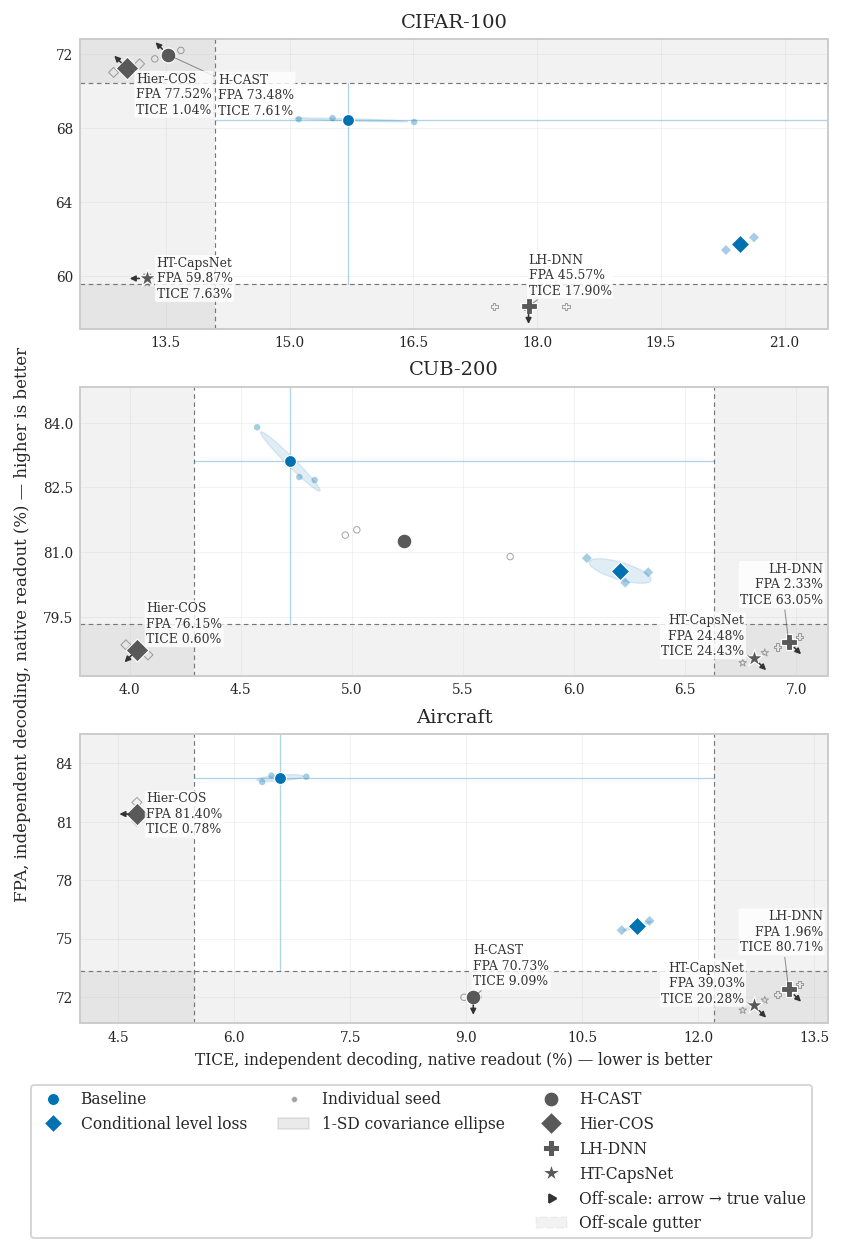

In [4]:
plot_tradeoff(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    reference_rows=reference_rows, reference_specs=REFERENCE_SPECS,
    encoding=ENCODING,
    decoder=DECODER, readout=READOUT,
)

## Selected-Run Effects Across Hierarchy Levels

Bars are matched-seed changes in coarse, middle, and fine accuracy from the
native HRN baseline, in percentage points. Only seeds present in both the run and
the baseline contribute. Each panel has its own vertical scale, because delta
ranges differ by an order of magnitude across datasets; read the printed values,
not the relative bar heights, when comparing datasets. The conditional baseline
isolates the effect of expressing the native objective as per-level terms; the
lex, HCC and LH-projection bars then show their selected-run effects against the
same canonical native baseline. These remain descriptive comparisons rather than
causal estimates. The LH-projection bars carry the extra caveat named at the top
of the notebook: its arm changes the branch architecture as well as the
gradient, so a level delta there is not attributable to the projector alone.

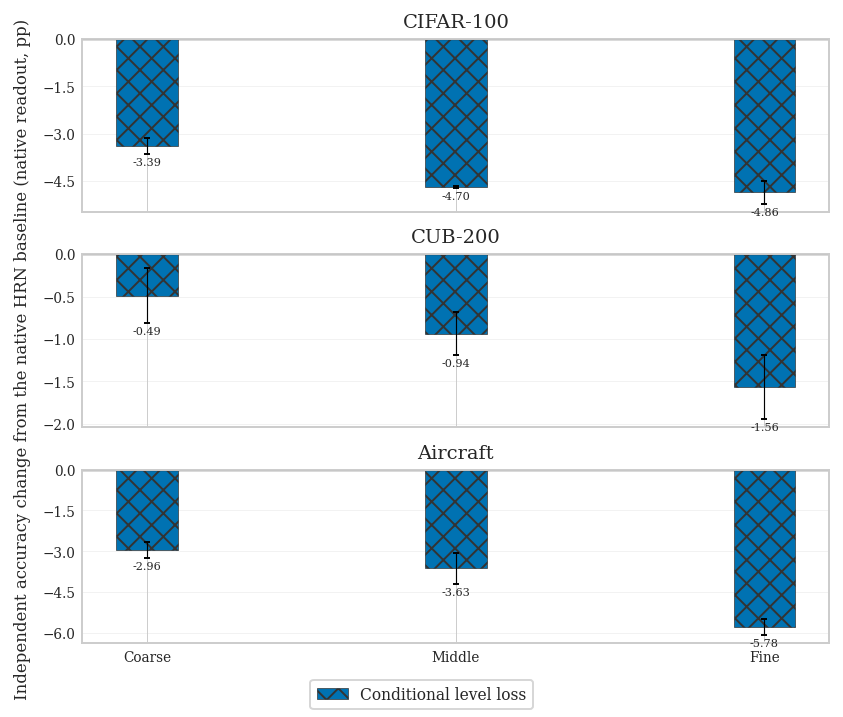

In [5]:
plot_level_accuracy_deltas(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    baseline_name='the native HRN baseline',
    decoder=DECODER, readout=READOUT,
)

## Run and Pareto Summary

A run is Pareto-optimal within a dataset when no other run of the same model
family has both higher-or-equal FPA and lower-or-equal TICE, with at least one
strict improvement. Reference models are not part of this comparison. AHD and
weighted AP are reported as additional columns but do not enter the Pareto test.

In [6]:
print_summary(rows, DATASETS)


CIFAR-100
  run                       n  epoch           FPA               TICE              AHD               weighted AP       status
  Baseline                  3  93.0 ± 2.6      68.45% ± 0.11     15.71% ± 0.72     0.646 ± 0.007     77.01% ± 0.10     Pareto-optimal
  Conditional level loss    2  90.5 ± 0.7      61.75% ± 0.48     20.46% ± 0.24     0.804 ± 0.008     72.33% ± 0.27     dominated by Baseline

CUB-200
  run                       n  epoch           FPA               TICE              AHD               weighted AP       status
  Baseline                  3  93.0 ± 3.6      83.10% ± 0.69     4.72% ± 0.13      0.242 ± 0.011     87.24% ± 0.38     Pareto-optimal
  Conditional level loss    3  79.0 ± 23.6     80.56% ± 0.29     6.21% ± 0.14      0.285 ± 0.009     85.82% ± 0.10     dominated by Baseline

Aircraft
  run                       n  epoch           FPA               TICE              AHD               weighted AP       status
  Baseline                  3  85.7 ± 13.1